In [1]:
import numpy as np
import json

import sys
import matplotlib.pyplot as plt

sys.path.append("..")

from syto.calibration.vector_scaling_calibrator import VectorScalingCalibrator
from syto.calibration.linear_calibrator import LinearCalibrator

In [2]:
lookup_wo_pool_nnls_vsc = VectorScalingCalibrator.load(
    "/home/nathan/Documents/Scolaire/7_Cesure/2_KU_Leuven/syto/Data/tmp_lookup_wo_pool_nnls_vsc/vector_scaling_calibrator_with_cv.joblib"
)
lookup_wo_pool_nnls_lincal = LinearCalibrator.load(
    "/home/nathan/Documents/Scolaire/7_Cesure/2_KU_Leuven/syto/Data/tmp_lookup_wo_pool_nnls_vsc/linear_calibrator.joblib"
)

In [3]:
labels_dict = json.load(
    open(
        "/home/nathan/Documents/Scolaire/7_Cesure/2_KU_Leuven/syto/App/labels_dict.json",
        "r",
    )
)
ctypes_names_list = list(labels_dict.values())

In [4]:
delta_a = lookup_wo_pool_nnls_vsc.model_.diag_delta.cpu().detach().numpy()
b = lookup_wo_pool_nnls_vsc.model_.b.cpu().detach().numpy()


def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=0)  # only difference


def vect_scaling(input, delta_a_, b_):
    return softmax((1 + delta_a_) * np.log(input) + b_)


def one_hot_encode(label, num_classes):
    return np.eye(num_classes)[label]

In [5]:
def lin_cal_pred(input, method):
    return lookup_wo_pool_nnls_lincal.predict(
        input.reshape(1, -1), norm_method=method
    ).reshape(-1)

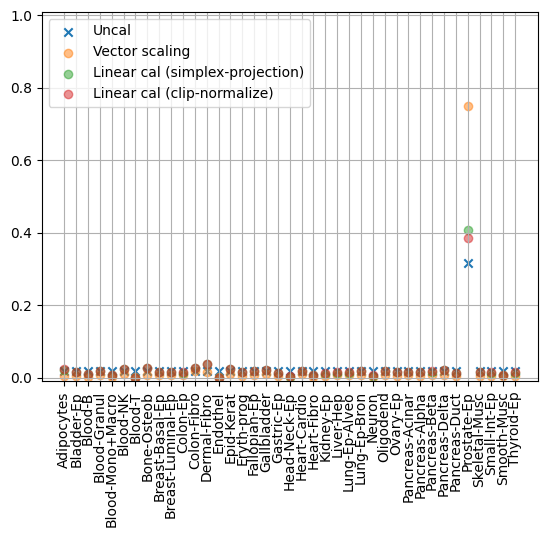

In [6]:
mixing_prop = 0.3
cell_type = "Prostate-Ep"
vector_dom_ctype = mixing_prop * one_hot_encode(
    ctypes_names_list.index(cell_type), 39
) + (1 - mixing_prop) * (np.full(39, 1 / 39))
vect_cal_vect_dom_ctype = vect_scaling(vector_dom_ctype, delta_a, b)
linear_cal_simplex_proj = lin_cal_pred(vector_dom_ctype, "simplex-projection")
linear_cal_clip_norm = lin_cal_pred(vector_dom_ctype, "clip-normalize")

plt.scatter(np.arange(39), vector_dom_ctype, label="Uncal", marker="x")
plt.scatter(np.arange(39), vect_cal_vect_dom_ctype, label="Vector scaling", alpha=0.5)
plt.scatter(
    np.arange(39),
    linear_cal_simplex_proj,
    label="Linear cal (simplex-projection)",
    alpha=0.5,
)
plt.scatter(
    np.arange(39), linear_cal_clip_norm, label="Linear cal (clip-normalize)", alpha=0.5
)
plt.ylim(-0.01, 1.01)
plt.grid(True)
plt.legend()
plt.xticks(np.arange(39), ctypes_names_list, rotation=90)
plt.show()

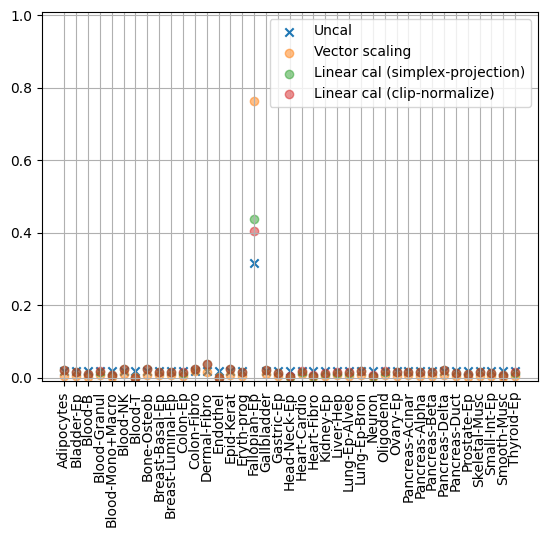

In [7]:
mixing_prop = 0.3
cell_type = "Fallopian-Ep"
vector_dom_ctype = mixing_prop * one_hot_encode(
    ctypes_names_list.index(cell_type), 39
) + (1 - mixing_prop) * (np.full(39, 1 / 39))
vect_cal_vect_dom_ctype = vect_scaling(vector_dom_ctype, delta_a, b)
linear_cal_simplex_proj = lin_cal_pred(vector_dom_ctype, "simplex-projection")
linear_cal_clip_norm = lin_cal_pred(vector_dom_ctype, "clip-normalize")

plt.scatter(np.arange(39), vector_dom_ctype, label="Uncal", marker="x")
plt.scatter(np.arange(39), vect_cal_vect_dom_ctype, label="Vector scaling", alpha=0.5)
plt.scatter(
    np.arange(39),
    linear_cal_simplex_proj,
    label="Linear cal (simplex-projection)",
    alpha=0.5,
)
plt.scatter(
    np.arange(39), linear_cal_clip_norm, label="Linear cal (clip-normalize)", alpha=0.5
)
plt.ylim(-0.01, 1.01)
plt.grid(True)
plt.legend()
plt.xticks(np.arange(39), ctypes_names_list, rotation=90)
plt.show()

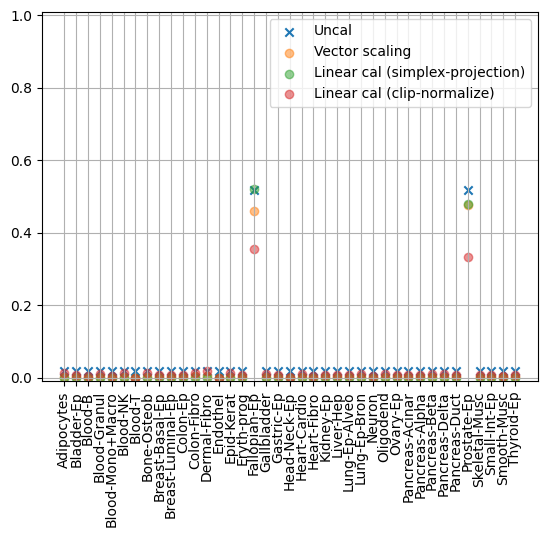

In [8]:
vector_dom_ctype = (
    0.5 * one_hot_encode(ctypes_names_list.index("Prostate-Ep"), 39)
    + 0.5 * one_hot_encode(ctypes_names_list.index("Fallopian-Ep"), 39)
    + (1 - mixing_prop) * (np.full(39, 1 / 39))
)
vect_cal_vect_dom_ctype = vect_scaling(vector_dom_ctype, delta_a, b)
linear_cal_simplex_proj = lin_cal_pred(vector_dom_ctype, "simplex-projection")
linear_cal_clip_norm = lin_cal_pred(vector_dom_ctype, "clip-normalize")

plt.scatter(np.arange(39), vector_dom_ctype, label="Uncal", marker="x")
plt.scatter(np.arange(39), vect_cal_vect_dom_ctype, label="Vector scaling", alpha=0.5)
plt.scatter(
    np.arange(39),
    linear_cal_simplex_proj,
    label="Linear cal (simplex-projection)",
    alpha=0.5,
)
plt.scatter(
    np.arange(39), linear_cal_clip_norm, label="Linear cal (clip-normalize)", alpha=0.5
)
plt.ylim(-0.01, 1.01)
plt.grid(True)
plt.legend()
plt.xticks(np.arange(39), ctypes_names_list, rotation=90)
plt.show()